In [1]:
import pandas as pd
import json
from pathlib import Path

print("Python is working!")

Python is working!


In [2]:
from pathlib import Path

DATA_PATH = Path("../data/triples.jsonl")

print("File path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

File path: ..\data\triples.jsonl
File exists: True


In [3]:
records = []

with open(DATA_PATH, "r", encoding="utf-8") as file:
    for line in file:
        records.append(json.loads(line))

print("Number of records:", len(records))

Number of records: 13204


In [4]:
records[0]

{'head': '476ae50a-a65c-11eb-8d02-1e003a340630',
 'head_type': 'Symptom',
 'relation': 'PRESENT_IN',
 'tail': '415105001',
 'tail_type': 'Condition',
 'properties': {'likelihood_condition_given_symptom': 'medium',
  'likelihood_symptom_given_condition': 'high'}}

In [5]:
df = pd.DataFrame(records)

df.head()

,head,head_type,relation,tail,tail_type,properties
0,476ae50a-a65c-11eb-8d02-1e003a340630,Symptom,PRESENT_IN,415105001,Condition,{'likelihood_condition_given_symptom': 'medium...
1,476b481a-a65c-11eb-8d02-1e003a340630,Symptom,PRESENT_IN,415105001,Condition,"{'likelihood_condition_given_symptom': 'high',..."
2,4726f7fa-a65c-11eb-8d02-1e003a340630,Symptom,PRESENT_IN,415105001,Condition,"{'likelihood_condition_given_symptom': 'rare',..."
3,473569ac-a65c-11eb-8d02-1e003a340630,Symptom,PRESENT_IN,415105001,Condition,"{'likelihood_condition_given_symptom': 'low', ..."
4,47846ef8-a65c-11eb-8d02-1e003a340630,Symptom,PRESENT_IN,415105001,Condition,{'likelihood_condition_given_symptom': 'medium...


In [6]:
df.shape

(13204, 6)

In [7]:
df.columns

Index(['head', 'head_type', 'relation', 'tail', 'tail_type', 'properties'], dtype='object')

In [8]:
df["relation"].value_counts()

relation
PRESENT_IN          10352
TREATED_BY           1558
IS_INFLUENCED_BY     1020
RELATED_TO            221
HAS_PREREQUISITE       53
Name: count, dtype: int64

In [9]:
df["relation"].value_counts()

relation
PRESENT_IN          10352
TREATED_BY           1558
IS_INFLUENCED_BY     1020
RELATED_TO            221
HAS_PREREQUISITE       53
Name: count, dtype: int64

In [11]:
symptom_condition_df = df[
    df["relation"] == "PRESENT_IN"
]

symptom_condition_df[
    ["head", "head_type", "tail", "tail_type"]
].head(20)

,head,head_type,tail,tail_type
0,476ae50a-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
1,476b481a-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
2,4726f7fa-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
3,473569ac-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
4,47846ef8-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
5,47600c02-a65c-11eb-8d02-1e003a340630,Symptom,415105001,Condition
6,e2f2cab0-d456-11eb-a77f-1e003a340630,Symptom,415105001,Condition
7,471ec3aa-a65c-11eb-8d02-1e003a340630,Symptom,10509002,Condition
8,471edde0-a65c-11eb-8d02-1e003a340630,Symptom,10509002,Condition
9,471f2d86-a65c-11eb-8d02-1e003a340630,Symptom,10509002,Condition


In [12]:
condition_specialty_df = df[
    df["relation"] == "TREATED_BY"
]

condition_specialty_df[
    ["head", "head_type", "tail", "tail_type"]
].head(20)

,head,head_type,tail,tail_type
10352,368009,Condition,1,Speciality
10353,28651003,Condition,1,Speciality
10354,3238004,Condition,1,Speciality
10355,89155008,Condition,1,Speciality
10356,398665005,Condition,1,Speciality
10357,59282003,Condition,1,Speciality
10358,237602007,Condition,1,Speciality
10359,132721000119104,Condition,1,Speciality
10360,161501007,Condition,1,Speciality
10361,233850007,Condition,1,Speciality


In [13]:
condition_specialty_df[["head", "tail"]].head(20)

,head,tail
10352,368009,1
10353,28651003,1
10354,3238004,1
10355,89155008,1
10356,398665005,1
10357,59282003,1
10358,237602007,1
10359,132721000119104,1
10360,161501007,1
10361,233850007,1


In [14]:
unique_symptoms = symptom_condition_df["head"].nunique()

print("Unique symptoms:", unique_symptoms)

Unique symptoms: 2559


In [15]:
unique_conditions = symptom_condition_df["tail"].nunique()

print("Unique conditions:", unique_conditions)

Unique conditions: 555


In [16]:
unique_specialties = condition_specialty_df["tail"].nunique()

print("Unique specialties:", unique_specialties)

Unique specialties: 39


In [17]:
symptoms_per_condition = (
    symptom_condition_df
    .groupby("tail")["head"]
    .nunique()
    .sort_values(ascending=False)
)

symptoms_per_condition.head(10)

tail
417357006    55
9014002      46
230690007    45
15628003     44
24700007     42
230572002    41
37869000     40
34000006     40
80327007     40
20511007     39
Name: head, dtype: int64

In [18]:
conditions_per_specialty = (
    condition_specialty_df
    .groupby("tail")["head"]
    .nunique()
    .sort_values(ascending=False)
)

conditions_per_specialty.head(10)

tail
44    292
6     205
8     139
10     90
17     81
9      80
3      78
4      67
7      61
40     60
Name: head, dtype: int64

In [19]:
print("===== BODHI-S DATASET SUMMARY =====")
print("Total records:", len(df))
print("Unique symptoms:", symptom_condition_df["head"].nunique())
print("Unique conditions:", symptom_condition_df["tail"].nunique())
print("Unique specialties:", condition_specialty_df["tail"].nunique())
print("Symptom-condition relationships:", len(symptom_condition_df))
print("Condition-specialty relationships:", len(condition_specialty_df))

===== BODHI-S DATASET SUMMARY =====
Total records: 13204
Unique symptoms: 2559
Unique conditions: 555
Unique specialties: 39
Symptom-condition relationships: 10352
Condition-specialty relationships: 1558


In [20]:
conditions = pd.read_csv("../data/nodes_condition.csv")
symptoms = pd.read_csv("../data/nodes_symptom.csv")
specialties = pd.read_csv("../data/nodes_speciality.csv")

print("Conditions:", conditions.shape)
print("Symptoms:", symptoms.shape)
print("Specialties:", specialties.shape)

Conditions: (779, 16)
Symptoms: (4037, 17)
Specialties: (39, 2)


In [21]:
conditions.columns

Index(['snomed_id', 'name', 'concept_type', 'type_condition', 'triage_level',
       'overall_likelihood', 'likelihood_male', 'likelihood_female',
       'likelihood_age_0_1', 'likelihood_age_1_5', 'likelihood_age_6_12',
       'likelihood_age_13_18', 'likelihood_age_19_30', 'likelihood_age_30_45',
       'likelihood_age_45_60', 'likelihood_age_60_plus'],
      dtype='object')

In [22]:
conditions.head()

,snomed_id,name,concept_type,type_condition,triage_level,overall_likelihood,likelihood_male,likelihood_female,likelihood_age_0_1,likelihood_age_1_5,likelihood_age_6_12,likelihood_age_13_18,likelihood_age_19_30,likelihood_age_30_45,likelihood_age_45_60,likelihood_age_60_plus
0,1012,FH Bruxism,FamilyHistory,medical_history,opd_managed,low,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
1,102424008,exposure to air pollution,Misc,medical_history,opd_managed,very_high,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,102430008,Consumed contaminated water,Misc,Event,opd_managed,high,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,102431007,Exposure to polluted water,Misc,medical_history,opd_managed,medium,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,102877006,Nulliparous women,Misc,medical_history,opd_managed,low,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [23]:
symptoms.columns

Index(['uuid', 'snomed_id', 'root_snomed_id', 'root_snomed_name', 'name',
       'triage_level', 'relevance_male', 'relevance_female', 'relation1_type',
       'child1_name', 'grouping1_selection_type', 'relation2_type',
       'child2_name', 'grouping2_selection_type', 'relation3_type',
       'child3_name', 'grouping3_selection_type'],
      dtype='object')

In [24]:
symptoms.head()

,uuid,snomed_id,root_snomed_id,root_snomed_name,name,triage_level,relevance_male,relevance_female,relation1_type,child1_name,grouping1_selection_type,relation2_type,child2_name,grouping2_selection_type,relation3_type,child3_name,grouping3_selection_type
0,00718bf4-9803-4cf6-af0d-fe2f2f444c85,NaN,438457000.0,Testicular swelling,Testicular swelling <laterality> unilateral,worrisome,NaN,NaN,laterality,unilateral,s,NaN,NaN,NaN,NaN,NaN,NaN
1,0075a985-8df0-4e5d-8a9b-28703b4fc047,298001000.0,298001000.0,Loss of body hair,Loss of body hair,opd_managed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,009240ed-9f08-4282-94fe-95019295f224,441708007.0,441708007.0,Swelling of jaw region,Swelling of jaw region,worrisome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00f7b9d6-16d1-4f28-ad41-218920889403,NaN,300874009.0,Ear swelling,Ear swelling <laterality> left,opd_managed,NaN,NaN,laterality,left,s,NaN,NaN,NaN,NaN,NaN,NaN
4,00fc66ab-7063-46d1-b7ad-1c1aa33c26dc,NaN,7973008.0,Abnormal vision,Abnormal vision <agg by> glare,worrisome,NaN,NaN,aggravated,glare,m,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
specialties.columns

Index(['id', 'name'], dtype='object')

In [26]:
specialties.head()

,id,name
0,1,Cardiologist
1,10,Neurologist
2,11,Nephrologist
3,12,Urologist
4,13,Ophthalmologist


In [27]:
print("CONDITIONS")
print(conditions.columns.tolist())
print(conditions.head(3))

print("\nSYMPTOMS")
print(symptoms.columns.tolist())
print(symptoms.head(3))

print("\nSPECIALTIES")
print(specialties.columns.tolist())
print(specialties.head(3))

CONDITIONS
['snomed_id', 'name', 'concept_type', 'type_condition', 'triage_level', 'overall_likelihood', 'likelihood_male', 'likelihood_female', 'likelihood_age_0_1', 'likelihood_age_1_5', 'likelihood_age_6_12', 'likelihood_age_13_18', 'likelihood_age_19_30', 'likelihood_age_30_45', 'likelihood_age_45_60', 'likelihood_age_60_plus']
   snomed_id                         name   concept_type   type_condition  \
0       1012                   FH Bruxism  FamilyHistory  medical_history   
1  102424008    exposure to air pollution           Misc  medical_history   
2  102430008  Consumed contaminated water           Misc            Event   

  triage_level overall_likelihood  likelihood_male  likelihood_female  \
0  opd_managed                low              1.0                1.0   
1  opd_managed          very_high              1.0                1.0   
2  opd_managed               high              1.0                1.0   

   likelihood_age_0_1  likelihood_age_1_5  likelihood_age_6_12  

In [28]:
conditions[["snomed_id", "name"]].head(10)

,snomed_id,name
0,1012,FH Bruxism
1,102424008,exposure to air pollution
2,102430008,Consumed contaminated water
3,102431007,Exposure to polluted water
4,102877006,Nulliparous women
5,102947004,Risky sexual behaviour
6,1033009,Arthritis of upper back
7,10509002,Acute bronchitis
8,10528009,Lupus Vulgaris
9,105651000119100,H/O Preeclampsia


In [29]:
print(symptoms.columns.tolist())
symptoms.head(5)

['uuid', 'snomed_id', 'root_snomed_id', 'root_snomed_name', 'name', 'triage_level', 'relevance_male', 'relevance_female', 'relation1_type', 'child1_name', 'grouping1_selection_type', 'relation2_type', 'child2_name', 'grouping2_selection_type', 'relation3_type', 'child3_name', 'grouping3_selection_type']


,uuid,snomed_id,root_snomed_id,root_snomed_name,name,triage_level,relevance_male,relevance_female,relation1_type,child1_name,grouping1_selection_type,relation2_type,child2_name,grouping2_selection_type,relation3_type,child3_name,grouping3_selection_type
0,00718bf4-9803-4cf6-af0d-fe2f2f444c85,NaN,438457000.0,Testicular swelling,Testicular swelling <laterality> unilateral,worrisome,NaN,NaN,laterality,unilateral,s,NaN,NaN,NaN,NaN,NaN,NaN
1,0075a985-8df0-4e5d-8a9b-28703b4fc047,298001000.0,298001000.0,Loss of body hair,Loss of body hair,opd_managed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,009240ed-9f08-4282-94fe-95019295f224,441708007.0,441708007.0,Swelling of jaw region,Swelling of jaw region,worrisome,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00f7b9d6-16d1-4f28-ad41-218920889403,NaN,300874009.0,Ear swelling,Ear swelling <laterality> left,opd_managed,NaN,NaN,laterality,left,s,NaN,NaN,NaN,NaN,NaN,NaN
4,00fc66ab-7063-46d1-b7ad-1c1aa33c26dc,NaN,7973008.0,Abnormal vision,Abnormal vision <agg by> glare,worrisome,NaN,NaN,aggravated,glare,m,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
specialties[["id", "name"]].head(10)

,id,name
0,1,Cardiologist
1,10,Neurologist
2,11,Nephrologist
3,12,Urologist
4,13,Ophthalmologist
5,14,Oncologist
6,15,Endocrinologist
7,16,Psychiatrist
8,17,General Surgeon
9,18,Rheumatologist


In [31]:
print("Condition ID type:", conditions["snomed_id"].dtype)
print("Specialty ID type:", specialties["id"].dtype)
print("Triple head type:", df["head"].dtype)
print("Triple tail type:", df["tail"].dtype)

Condition ID type: int64
Specialty ID type: int64
Triple head type: object
Triple tail type: object


In [32]:
print("SYMPTOM COLUMNS:")
print(symptoms.columns.tolist())

print("\nFIRST 10 SYMPTOMS:")
print(symptoms.head(10))

SYMPTOM COLUMNS:
['uuid', 'snomed_id', 'root_snomed_id', 'root_snomed_name', 'name', 'triage_level', 'relevance_male', 'relevance_female', 'relation1_type', 'child1_name', 'grouping1_selection_type', 'relation2_type', 'child2_name', 'grouping2_selection_type', 'relation3_type', 'child3_name', 'grouping3_selection_type']

FIRST 10 SYMPTOMS:
                                   uuid    snomed_id  root_snomed_id  \
0  00718bf4-9803-4cf6-af0d-fe2f2f444c85          NaN    4.384570e+08   
1  0075a985-8df0-4e5d-8a9b-28703b4fc047  298001000.0    2.980010e+08   
2  009240ed-9f08-4282-94fe-95019295f224  441708007.0    4.417080e+08   
3  00f7b9d6-16d1-4f28-ad41-218920889403          NaN    3.008740e+08   
4  00fc66ab-7063-46d1-b7ad-1c1aa33c26dc          NaN    7.973008e+06   
5  0122fe8a-3dad-4f62-9a51-f902f9659cc4          NaN    2.718070e+08   
6  016384c0-dfd5-4100-841c-2abf94d5ff5e          NaN    1.071000e+12   
7  01ec010a-29fa-4f82-8017-4d0150a9ebca   42134006.0    4.213401e+07   
8  01fa1bb

In [33]:
print("CONDITION COLUMNS:")
print(conditions.columns.tolist())

print("\nFIRST 10 CONDITIONS:")
print(conditions[["snomed_id", "name"]].head(10))

CONDITION COLUMNS:
['snomed_id', 'name', 'concept_type', 'type_condition', 'triage_level', 'overall_likelihood', 'likelihood_male', 'likelihood_female', 'likelihood_age_0_1', 'likelihood_age_1_5', 'likelihood_age_6_12', 'likelihood_age_13_18', 'likelihood_age_19_30', 'likelihood_age_30_45', 'likelihood_age_45_60', 'likelihood_age_60_plus']

FIRST 10 CONDITIONS:
         snomed_id                         name
0             1012                   FH Bruxism
1        102424008    exposure to air pollution
2        102430008  Consumed contaminated water
3        102431007   Exposure to polluted water
4        102877006            Nulliparous women
5        102947004       Risky sexual behaviour
6          1033009      Arthritis of upper back
7         10509002             Acute bronchitis
8         10528009               Lupus Vulgaris
9  105651000119100             H/O Preeclampsia


In [34]:
print("ALL SPECIALTIES:")
print(specialties[["id", "name"]].to_string(index=False))

ALL SPECIALTIES:
 id                         name
  1                 Cardiologist
 10                  Neurologist
 11                 Nephrologist
 12                    Urologist
 13              Ophthalmologist
 14                   Oncologist
 15              Endocrinologist
 16                 Psychiatrist
 17              General Surgeon
 18               Rheumatologist
  2                      Dentist
 21                Pulmonologist
 22                  Radiologist
 23              Plastic Surgeon
 24                Spine Surgeon
 25               IVF Specialist
 27              Physiotherapist
 29                  Intensivist
  3                Dermatologist
 30              Chest Physician
 31                Diabetologist
 32                 Immunologist
 33 Oral & Maxillofacial Surgeon
 35                  Andrologist
 39       Pediatric Nephrologist
  4                          ENT
 40                 Obstetrician
 41          Clinical geneticist
 42           Allergy spec

In [36]:
# Make condition IDs the same type
conditions["snomed_id"] = conditions["snomed_id"].astype(str)
symptom_edges["condition_id"] = symptom_edges["condition_id"].astype(str)

In [37]:
symptom_edges = symptom_edges.merge(
    conditions[["snomed_id", "name"]],
    left_on="condition_id",
    right_on="snomed_id",
    how="left"
)

symptom_edges = symptom_edges.rename(
    columns={"name": "condition_name"}
)

In [38]:
symptom_edges[
    ["symptom_name", "condition_name"]
].head(20)

,symptom_name,condition_name
0,Abdominal pain in pregnancy,Abruptio Placenta
1,Abdominal pain in pregnancy <severity> severe,Abruptio Placenta
2,Back pain,Abruptio Placenta
3,Dizziness,Abruptio Placenta
4,Reduced fetal movement,Abruptio Placenta
5,Abnormal vaginal bleeding,Abruptio Placenta
6,Abdominal pain in pregnancy <char> tender uterus,Abruptio Placenta
7,Cough <since> 5 day to 14 days,Acute bronchitis
8,Cough <since> more than 2 week,Acute bronchitis
9,Cough <char> productive cough <char> yellow sp...,Acute bronchitis


In [39]:
print("Condition names missing:",
      symptom_edges["condition_name"].isna().sum())

Condition names missing: 0


In [40]:
specialty_edges = condition_specialty_df[["head", "tail"]].copy()

specialty_edges = specialty_edges.rename(
    columns={
        "head": "condition_id",
        "tail": "specialty_id"
    }
)

In [41]:
specialty_edges["condition_id"] = specialty_edges["condition_id"].astype(str)
specialty_edges["specialty_id"] = specialty_edges["specialty_id"].astype(int)

conditions["snomed_id"] = conditions["snomed_id"].astype(str)
specialties["id"] = specialties["id"].astype(int)

In [42]:
specialty_edges = specialty_edges.merge(
    conditions[["snomed_id", "name"]],
    left_on="condition_id",
    right_on="snomed_id",
    how="left"
)

specialty_edges = specialty_edges.rename(
    columns={"name": "condition_name"}
)

specialty_edges = specialty_edges.merge(
    specialties[["id", "name"]],
    left_on="specialty_id",
    right_on="id",
    how="left"
)

specialty_edges = specialty_edges.rename(
    columns={"name": "specialty_name"}
)

In [43]:
print("Condition names missing:",
      specialty_edges["condition_name"].isna().sum())

print("Specialty names missing:",
      specialty_edges["specialty_name"].isna().sum())

specialty_edges[
    ["condition_name", "specialty_name"]
].head(20)

Condition names missing: 0
Specialty names missing: 0


,condition_name,specialty_name
0,Valvular heart disease,Cardiologist
1,Orthostatic hypotension,Cardiologist
2,Pericarditis,Cardiologist
3,Scleroderma,Cardiologist
4,Reflex syncope,Cardiologist
5,Pulmonary Embolism,Cardiologist
6,Metabolic syndrome,Cardiologist
7,Hypertensive emergency,Cardiologist
8,H/O Hypertension,Cardiologist
9,Infective endocarditis,Cardiologist


In [44]:
print(specialties["name"].tolist())

['Cardiologist', 'Neurologist', 'Nephrologist', 'Urologist', 'Ophthalmologist', 'Oncologist', 'Endocrinologist', 'Psychiatrist', 'General Surgeon', 'Rheumatologist', 'Dentist', 'Pulmonologist', 'Radiologist', 'Plastic Surgeon', 'Spine Surgeon', 'IVF Specialist', 'Physiotherapist', 'Intensivist', 'Dermatologist', 'Chest Physician', 'Diabetologist', 'Immunologist', 'Oral & Maxillofacial Surgeon', 'Andrologist', 'Pediatric Nephrologist', 'ENT', 'Obstetrician', 'Clinical geneticist', 'Allergy specialist', 'Clinical haematologist', 'Internal medicine specialist', 'Trauma Specialist', 'Vascular medicine specialist', 'Neurosurgeon', 'Gastroenterologist', 'General Physician', 'Gynaecologist', 'Orthopedic', 'Paediatrician']


In [45]:
for i, name in enumerate(specialties["name"], start=1):
    print(i, "→", name)

1 → Cardiologist
2 → Neurologist
3 → Nephrologist
4 → Urologist
5 → Ophthalmologist
6 → Oncologist
7 → Endocrinologist
8 → Psychiatrist
9 → General Surgeon
10 → Rheumatologist
11 → Dentist
12 → Pulmonologist
13 → Radiologist
14 → Plastic Surgeon
15 → Spine Surgeon
16 → IVF Specialist
17 → Physiotherapist
18 → Intensivist
19 → Dermatologist
20 → Chest Physician
21 → Diabetologist
22 → Immunologist
23 → Oral & Maxillofacial Surgeon
24 → Andrologist
25 → Pediatric Nephrologist
26 → ENT
27 → Obstetrician
28 → Clinical geneticist
29 → Allergy specialist
30 → Clinical haematologist
31 → Internal medicine specialist
32 → Trauma Specialist
33 → Vascular medicine specialist
34 → Neurosurgeon
35 → Gastroenterologist
36 → General Physician
37 → Gynaecologist
38 → Orthopedic
39 → Paediatrician


In [46]:
def map_department(specialty):
    s = specialty.lower()

    if "cardio" in s:
        return "Cardiology"
    elif "neuro" in s:
        return "Neurology"
    elif "pulmon" in s or "respir" in s:
        return "Pulmonology"
    elif "dermat" in s or "skin" in s:
        return "Dermatology"
    elif "gastro" in s:
        return "Gastroenterology"
    elif "ent" in s or "otolaryng" in s:
        return "ENT"
    elif "orthop" in s:
        return "Orthopedics"
    elif "ophthalm" in s or "eye" in s:
        return "Ophthalmology"
    elif "gynec" in s or "obstetric" in s:
        return "Gynecology"
    else:
        return "General Medicine"

In [48]:
specialty_edges["department"] = specialty_edges["specialty_name"].apply(
    map_department
)

In [49]:
specialty_mapping = (
    specialty_edges[["specialty_name", "department"]]
    .drop_duplicates()
    .sort_values("specialty_name")
)

print(specialty_mapping.to_string(index=False))

              specialty_name       department
          Allergy specialist General Medicine
                 Andrologist General Medicine
                Cardiologist       Cardiology
             Chest Physician General Medicine
         Clinical geneticist General Medicine
      Clinical haematologist General Medicine
                     Dentist              ENT
               Dermatologist      Dermatology
               Diabetologist General Medicine
                         ENT              ENT
             Endocrinologist General Medicine
          Gastroenterologist Gastroenterology
           General Physician General Medicine
             General Surgeon General Medicine
               Gynaecologist General Medicine
              IVF Specialist General Medicine
                Immunologist General Medicine
                 Intensivist General Medicine
Internal medicine specialist General Medicine
                Nephrologist General Medicine
                 Neurologist      

In [50]:
print("\nDepartment counts:")
print(specialty_edges["department"].value_counts())


Department counts:
department
General Medicine    977
Orthopedics         139
Neurology           114
Dermatology          78
ENT                  76
Gynecology           60
Gastroenterology     38
Ophthalmology        32
Pulmonology          30
Cardiology           14
Name: count, dtype: int64


In [51]:
departments = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Neurology",
    "Dermatology",
    "Gastroenterology",
    "ENT",
    "Orthopedics",
    "Ophthalmology",
    "Gynecology"
]

print("\nDepartments:", departments)
print("Number of departments:", len(departments))


Departments: ['General Medicine', 'Cardiology', 'Pulmonology', 'Neurology', 'Dermatology', 'Gastroenterology', 'ENT', 'Orthopedics', 'Ophthalmology', 'Gynecology']
Number of departments: 10


In [52]:
condition_department = (
    specialty_edges
    .groupby(["condition_id", "department"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["condition_id", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("condition_id")
)

condition_department = condition_department[
    ["condition_id", "department"]
]

print("Conditions with department:",
      len(condition_department))

condition_department.head(10)

Conditions with department: 567


,condition_id,department
0,1033009,General Medicine
2,10509002,General Medicine
4,10528009,Dermatology
6,10623005,General Medicine
9,10743008,General Medicine
10,109385007,Dermatology
13,110030002,Neurology
14,111196000,Dermatology
17,111202002,Dermatology
19,111243002,Orthopedics


In [53]:
symptom_matrix = pd.crosstab(
    symptom_edges["condition_id"],
    symptom_edges["symptom_name"]
)

print("Matrix shape:", symptom_matrix.shape)

symptom_matrix.head()

Matrix shape: (555, 2559)


symptom_name,Abdominal bloating,Abdominal bloating <since> More than 1 month,Abdominal discomfort,Abdominal discomfort <since> 1 week to 4 weeks,Abdominal discomfort <since> More than 1 month,Abdominal pain,Abdominal pain <agg by> after caffeine consumption,Abdominal pain <agg by> at night,Abdominal pain <agg by> on bending forward,Abdominal pain <agg by> on food intake,...,Wound hematoma,Wound hematoma <since> 1 week to 4 weeks,Wound hematoma <since> 3 days to 7 days,Wound pain,Wound pain <severity> Moderate,Wound pain <severity> Severe,Wound pain <since> 1 week to 4 weeks,Wound pain <since> 3 days to 7 days,Xanthelasma,lip swelling
condition_id,,,,,,,,,,,,,,,,,,,,,
1033009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10509002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10528009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10623005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10743008,1,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [54]:
symptom_matrix = (symptom_matrix > 0).astype(int)

symptom_matrix.index.name = "condition_id"

print("Rows:", symptom_matrix.shape[0])
print("Symptom features:", symptom_matrix.shape[1])

Rows: 555
Symptom features: 2559


In [56]:
# Convert condition IDs to strings for merging
condition_department["condition_id"] = (
    condition_department["condition_id"].astype(str)
)

conditions["snomed_id"] = conditions["snomed_id"].astype(str)

# Reset matrix index
department_dataset = symptom_matrix.reset_index()

# Add condition names
department_dataset = department_dataset.merge(
    conditions[["snomed_id", "name"]],
    left_on="condition_id",
    right_on="snomed_id",
    how="left"
)

department_dataset = department_dataset.rename(
    columns={"name": "condition_name"}
)

department_dataset = department_dataset.drop(
    columns=["snomed_id"]
)

# Add department
department_dataset = department_dataset.merge(
    condition_department,
    on="condition_id",
    how="left"
)

print("Final dataset shape:", department_dataset.shape)

department_dataset.head()

Final dataset shape: (555, 2562)


,condition_id,Abdominal bloating,Abdominal bloating <since> More than 1 month,Abdominal discomfort,Abdominal discomfort <since> 1 week to 4 weeks,Abdominal discomfort <since> More than 1 month,Abdominal pain,Abdominal pain <agg by> after caffeine consumption,Abdominal pain <agg by> at night,Abdominal pain <agg by> on bending forward,...,Wound hematoma <since> 3 days to 7 days,Wound pain,Wound pain <severity> Moderate,Wound pain <severity> Severe,Wound pain <since> 1 week to 4 weeks,Wound pain <since> 3 days to 7 days,Xanthelasma,lip swelling,condition_name,department
0,1033009,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Arthritis of upper back,General Medicine
1,10509002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Acute bronchitis,General Medicine
2,10528009,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Lupus Vulgaris,Dermatology
3,10623005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fibrous dysplasia,General Medicine
4,10743008,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,Irritable bowel syndrome,General Medicine


In [58]:
print("Missing departments:",
      department_dataset["department"].isna().sum())

print("\nDepartment distribution:")
print(department_dataset["department"].value_counts())

print("\nFinal columns:", len(department_dataset.columns))

# Save dataset
department_dataset.to_csv(
    "../data/department_dataset.csv",
    index=False
)

print("\n✅ department_dataset.csv saved successfully!")

Missing departments: 2

Department distribution:
department
General Medicine    378
Orthopedics          51
Dermatology          39
ENT                  35
Neurology            22
Ophthalmology        14
Gastroenterology     10
Cardiology            4
Name: count, dtype: int64

Final columns: 2562

✅ department_dataset.csv saved successfully!


In [59]:
print("Dataset shape:", department_dataset.shape)

print("\nColumns:")
print(department_dataset.columns[:10].tolist())

print("\nMissing values:")
print(department_dataset.isna().sum().sum())

print("\nDuplicate rows:")
print(department_dataset.duplicated().sum())

Dataset shape: (555, 2562)

Columns:
['condition_id', 'Abdominal bloating', 'Abdominal bloating <since> More than 1 month', 'Abdominal discomfort', 'Abdominal discomfort <since> 1 week to 4 weeks', 'Abdominal discomfort <since> More than 1 month', 'Abdominal pain', 'Abdominal pain <agg by> after caffeine consumption', 'Abdominal pain <agg by> at night', 'Abdominal pain <agg by> on bending forward']

Missing values:
2

Duplicate rows:
0


In [61]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl (7.2 MB)
U

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


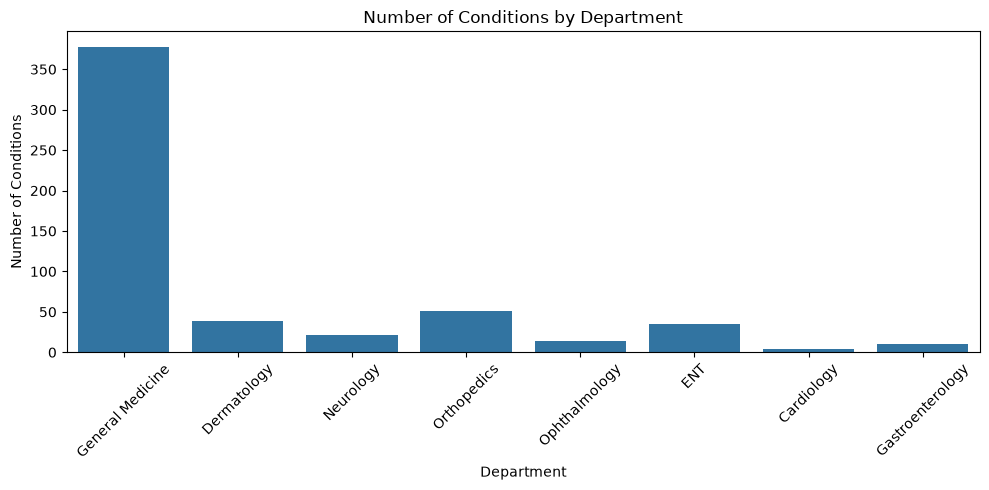

In [63]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=department_dataset,
    x="department"
)

plt.title("Number of Conditions by Department")
plt.xlabel("Department")
plt.ylabel("Number of Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
symptom_columns = [
    col for col in department_dataset.columns
    if col not in ["condition_id", "condition_name", "department"]
]

symptom_frequency = (
    department_dataset[symptom_columns]
    .sum()
    .sort_values(ascending=False)
)

print("Top 20 symptoms:")
print(symptom_frequency.head(20))

Top 20 symptoms:
Fever                              145
Fatigue                            126
Headache                           109
Vomit                               89
Malaise                             81
Abdominal pain                      79
Muscle weakness                     69
Nausea                              67
Breathlessness                      57
Weight decreased                    54
Discoloration of skin               52
Joint pain                          51
Cough                               48
Paresthesia                         46
Delirium                            45
Skin rash                           42
Dizziness                           42
Seizure                             41
Chest pain                          40
Muscle weakness <loc> localised     40
dtype: int64


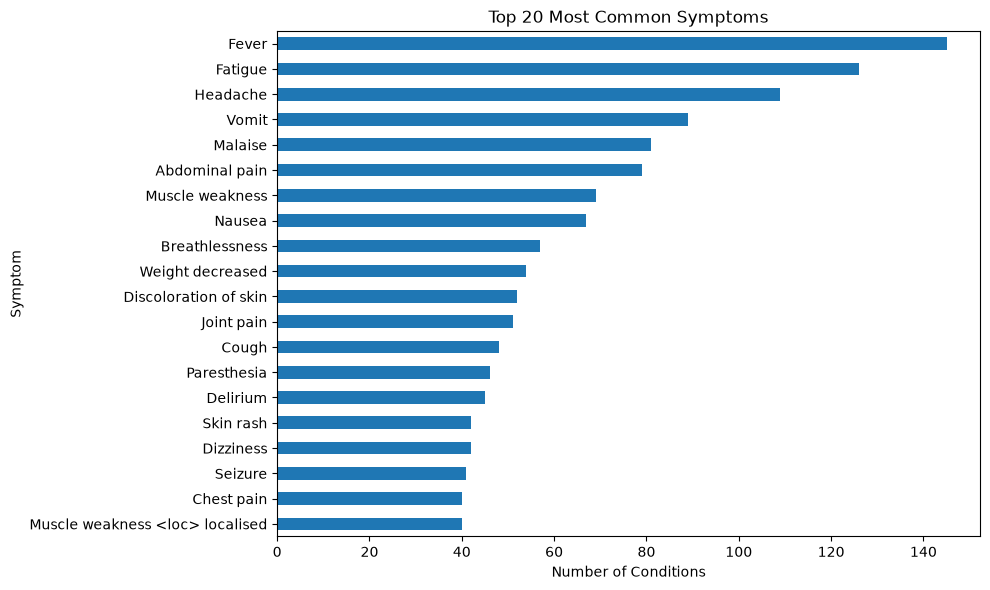

In [65]:
plt.figure(figsize=(10, 6))

symptom_frequency.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Most Common Symptoms")
plt.xlabel("Number of Conditions")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()

In [66]:
print("===== DATASET QUALITY CHECK =====")

print("Total conditions:", len(department_dataset))
print("Total symptoms:", len(symptom_columns))
print("Total departments:",
      department_dataset["department"].nunique())

print("\nMissing values:",
      department_dataset.isna().sum().sum())

print("Duplicate rows:",
      department_dataset.duplicated().sum())

print("\nDepartment distribution:")
print(department_dataset["department"].value_counts())

===== DATASET QUALITY CHECK =====
Total conditions: 555
Total symptoms: 2559
Total departments: 8

Missing values: 2
Duplicate rows: 0

Department distribution:
department
General Medicine    378
Orthopedics          51
Dermatology          39
ENT                  35
Neurology            22
Ophthalmology        14
Gastroenterology     10
Cardiology            4
Name: count, dtype: int64


In [67]:
missing_rows = department_dataset[
    department_dataset["department"].isna()
]

print(missing_rows[
    ["condition_id", "condition_name", "department"]
])

    condition_id          condition_name department
276         3868       Kennedy's disease        NaN
441      6836001  Brachial plexus injury        NaN


In [68]:
missing_conditions = missing_rows["condition_id"].tolist()

print(
    specialty_edges[
        specialty_edges["condition_id"].isin(missing_conditions)
    ][
        ["condition_id", "condition_name", "specialty_name", "department"]
    ].to_string(index=False)
)

Empty DataFrame
Columns: [condition_id, condition_name, specialty_name, department]
Index: []


In [69]:
print("Available departments:")
print(sorted(department_dataset["department"].dropna().unique()))

print("\nMissing department rows:", len(missing_rows))

Available departments:
['Cardiology', 'Dermatology', 'ENT', 'Gastroenterology', 'General Medicine', 'Neurology', 'Ophthalmology', 'Orthopedics']

Missing department rows: 2


In [70]:
# Remove rows without a department
department_dataset = department_dataset.dropna(
    subset=["department"]
).copy()

print("Dataset after cleaning:", department_dataset.shape)
print("Missing departments:",
      department_dataset["department"].isna().sum())

Dataset after cleaning: (553, 2562)
Missing departments: 0


In [71]:
from sklearn.model_selection import train_test_split

# Features
symptom_columns = [
    col for col in department_dataset.columns
    if col not in ["condition_id", "condition_name", "department"]
]

X = department_dataset[symptom_columns]
y = department_dataset["department"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", y.nunique())
print("\nClasses:")
print(sorted(y.unique()))

X shape: (553, 2559)
y shape: (553,)
Classes: 8

Classes:
['Cardiology', 'Dermatology', 'ENT', 'Gastroenterology', 'General Medicine', 'Neurology', 'Ophthalmology', 'Orthopedics']


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 442
Testing samples: 111


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Model 2: Linear SVM
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

# Model 3: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
logistic_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("✅ All 3 models trained successfully!")

✅ All 3 models trained successfully!


In [74]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": logistic_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Weighted F1": f1
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

              Model  Accuracy  Weighted F1
Logistic Regression  0.738739     0.737482
         Linear SVM  0.792793     0.779789
      Random Forest  0.702703     0.629104


In [75]:
best_model_name = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:",
      results_df.loc[
          results_df["Model"] == best_model_name, "Accuracy"
      ].iloc[0])

print("Weighted F1:",
      results_df.loc[
          results_df["Model"] == best_model_name, "Weighted F1"
      ].iloc[0])

Best Model: Linear SVM
Accuracy: 0.7927927927927928
Weighted F1: 0.7797891072525768


In [76]:
from sklearn.metrics import classification_report

best_predictions = best_model.predict(X_test)

print("===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

===== CLASSIFICATION REPORT =====
                  precision    recall  f1-score   support

      Cardiology       0.00      0.00      0.00         1
     Dermatology       0.67      0.75      0.71         8
             ENT       1.00      0.57      0.73         7
Gastroenterology       1.00      0.50      0.67         2
General Medicine       0.83      0.88      0.85        76
       Neurology       0.00      0.00      0.00         4
   Ophthalmology       0.67      0.67      0.67         3
     Orthopedics       0.73      0.80      0.76        10

        accuracy                           0.79       111
       macro avg       0.61      0.52      0.55       111
    weighted avg       0.78      0.79      0.78       111



<Figure size 1000x700 with 0 Axes>

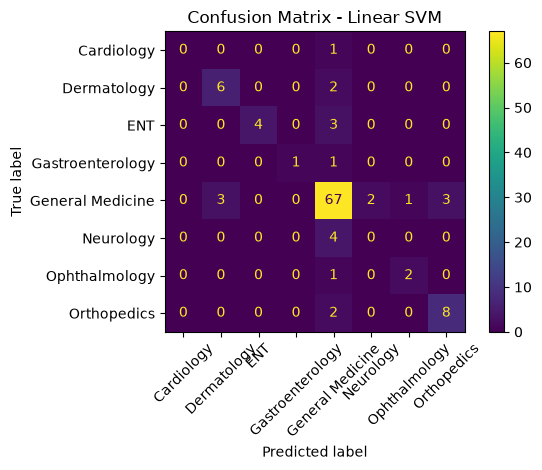

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    xticks_rotation=45
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [78]:
import joblib
from pathlib import Path

model_package = {
    "model": best_model,
    "features": symptom_columns,
    "departments": sorted(y.unique())
}

MODEL_PATH = Path("../models/department_classifier.pkl")

joblib.dump(
    model_package,
    MODEL_PATH
)

print("✅ Model saved successfully!")
print("Location:", MODEL_PATH)

✅ Model saved successfully!
Location: ..\models\department_classifier.pkl


In [79]:
loaded_package = joblib.load(
    "../models/department_classifier.pkl"
)

print("Model:", type(loaded_package["model"]).__name__)
print("Number of features:", len(loaded_package["features"]))
print("Departments:", loaded_package["departments"])

print("\n✅ Model loading verified successfully!")

Model: LinearSVC
Number of features: 2559
Departments: ['Cardiology', 'Dermatology', 'ENT', 'Gastroenterology', 'General Medicine', 'Neurology', 'Ophthalmology', 'Orthopedics']

✅ Model loading verified successfully!


In [80]:
import sys
from pathlib import Path

# Tell Python where our app files are
sys.path.append(str(Path("../app").resolve()))

from triage import predict_department
from safety import check_red_flags

In [81]:
test_symptoms = ["Headache", "Dizziness"]

print("Selected symptoms:", test_symptoms)

print("Safety check:",
      check_red_flags(test_symptoms))

print("Predicted department:",
      predict_department(test_symptoms))

Selected symptoms: ['Headache', 'Dizziness']
Safety check: False
Predicted department: General Medicine


c:\Users\tharu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [82]:
emergency_symptoms = [
    "Chest discomfort",
    "Difficulty breathing"
]

print("Selected symptoms:", emergency_symptoms)

print("Safety check:",
      check_red_flags(emergency_symptoms))

Selected symptoms: ['Chest discomfort', 'Difficulty breathing']
Safety check: True
